Check P sums:
P[0,0] sum = 1.0
P[0,1] sum = 1.0
P[1,0] sum = 1.0
P[1,1] sum = 1.0
P[2,0] sum = 0.0
P[2,1] sum = 1.0

R matrix:
 [[ 4.  1.]
 [-3.  1.]
 [ 0.  0.]]

V_pi:
High : 18.108099899798006
Low : 9.999991791689899
Charging : 16.297289909818208


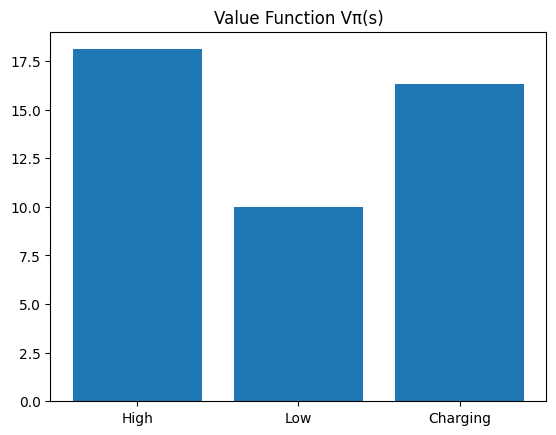

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# MDP Definition
# -----------------------------
STATES = ['High', 'Low', 'Charging']
ACTIONS = ['Search', 'Wait']

n_states = 3
n_actions = 2

gamma = 0.9
theta = 1e-6

P = np.zeros((n_states, n_actions, n_states))
R = np.zeros((n_states, n_actions))

# High
P[0,0,0] = 0.7
P[0,0,1] = 0.3
R[0,0] = 4

P[0,1,0] = 1.0
R[0,1] = 1

# Low
P[1,0,0] = 0.4
P[1,0,1] = 0.6
R[1,0] = -3

P[1,1,1] = 1.0
R[1,1] = 1

# Charging
P[2,1,0] = 1.0
R[2,1] = 0

# -----------------------------
# Verification
# -----------------------------
print("Check P sums:")
for s in range(n_states):
    for a in range(n_actions):
        print(f"P[{s},{a}] sum =", np.sum(P[s,a,:]))

print("\nR matrix:\n", R)

# -----------------------------
# Policy Evaluation
# -----------------------------
def policy_evaluation(P, R, policy, gamma, theta):
    V = np.zeros(n_states)

    while True:
        delta = 0
        for s in range(n_states):
            v = V[s]
            a = policy[s]

            V[s] = sum(P[s,a,s_] * (R[s,a] + gamma * V[s_])
                       for s_ in range(n_states))

            delta = max(delta, abs(v - V[s]))

        if delta < theta:
            break

    return V

# Given policy
policy = [0, 1, 1]

V = policy_evaluation(P, R, policy, gamma, theta)

print("\nV_pi:")
for i, s in enumerate(STATES):
    print(s, ":", V[i])

# -----------------------------
# Plot
# -----------------------------
plt.bar(STATES, V)
plt.title("Value Function Vπ(s)")
plt.show()

Optimal V*: [18.10809899  9.99999088 16.29728818]

Optimal Policy:
High -> Search
Low -> Wait
Charging -> Wait


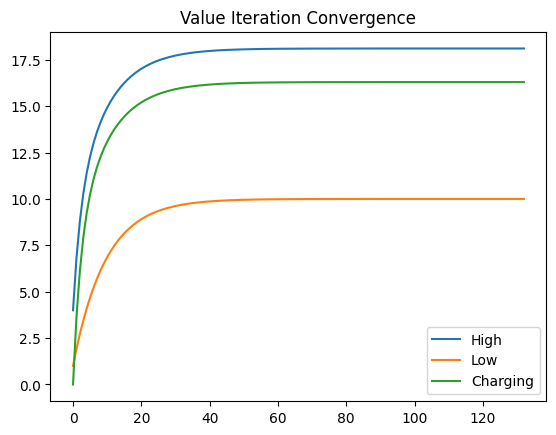

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# (Reuse same P, R, STATES, ACTIONS, gamma, theta)

def value_iteration(P, R, gamma, theta):
    V = np.zeros(len(P))
    history = []

    while True:
        V_new = np.copy(V)

        for s in range(len(P)):
            Q = []
            for a in range(len(P[0])):
                q = sum(P[s,a,s_] * (R[s,a] + gamma * V[s_])
                        for s_ in range(len(P)))
                Q.append(q)

            V_new[s] = max(Q)

        history.append(V_new.copy())

        if np.max(np.abs(V - V_new)) < theta:
            break

        V = V_new

    return V, history


def extract_policy(V, P, R, gamma):
    policy = np.zeros(len(P), dtype=int)

    for s in range(len(P)):
        Q = []
        for a in range(len(P[0])):
            q = sum(P[s,a,s_] * (R[s,a] + gamma * V[s_])
                    for s_ in range(len(P)))
            Q.append(q)

        policy[s] = np.argmax(Q)

    return policy


V_star, history = value_iteration(P, R, gamma, theta)

policy = extract_policy(V_star, P, R, gamma)

print("Optimal V*:", V_star)

print("\nOptimal Policy:")
for i, s in enumerate(STATES):
    print(s, "->", ACTIONS[policy[i]])

# Plot convergence
history = np.array(history)

for i in range(3):
    plt.plot(history[:,i], label=STATES[i])

plt.title("Value Iteration Convergence")
plt.legend()
plt.show()

Final Policy:
High -> Search
Low -> Wait
Charging -> Wait


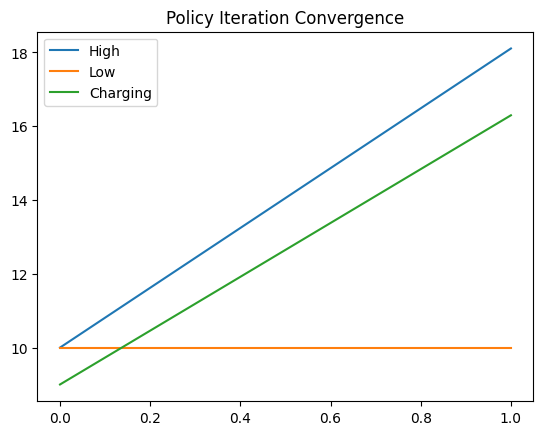


Policy History:
Iteration 0 : ['Wait', 'Wait', 'Wait']
Iteration 1 : ['Search', 'Wait', 'Wait']


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# (Reuse same P, R, STATES, ACTIONS, gamma, theta)

def policy_evaluation(P, R, policy, gamma, theta):
    V = np.zeros(len(P))

    while True:
        delta = 0
        for s in range(len(P)):
            v = V[s]
            a = policy[s]

            V[s] = sum(P[s,a,s_] * (R[s,a] + gamma * V[s_])
                       for s_ in range(len(P)))

            delta = max(delta, abs(v - V[s]))

        if delta < theta:
            break

    return V


def policy_improvement(V, P, R, gamma, policy):
    new_policy = np.zeros(len(P), dtype=int)
    stable = True

    for s in range(len(P)):
        old = policy[s]

        Q = []
        for a in range(len(P[0])):
            q = sum(P[s,a,s_] * (R[s,a] + gamma * V[s_])
                    for s_ in range(len(P)))
            Q.append(q)

        best = np.argmax(Q)
        new_policy[s] = best

        if best != old:
            stable = False

    return new_policy, stable


def policy_iteration(P, R, gamma, theta):
    policy = np.ones(len(P), dtype=int)  # start with Wait
    V_history = []
    policy_history = []

    while True:
        V = policy_evaluation(P, R, policy, gamma, theta)
        policy_history.append(policy.copy())
        V_history.append(V.copy())

        new_policy, stable = policy_improvement(V, P, R, gamma, policy)

        policy = new_policy

        if stable:
            break

    return policy, V, V_history, policy_history


final_policy, V_final, V_hist, P_hist = policy_iteration(P, R, gamma, theta)

print("Final Policy:")
for i, s in enumerate(STATES):
    print(s, "->", ACTIONS[final_policy[i]])

# Plot V convergence
V_hist = np.array(V_hist)

for i in range(3):
    plt.plot(V_hist[:,i], label=STATES[i])

plt.title("Policy Iteration Convergence")
plt.legend()
plt.show()

# Policy table
print("\nPolicy History:")
for i, p in enumerate(P_hist):
    print("Iteration", i, ":", [ACTIONS[a] for a in p])